# [Video RAG] 프레임별 이미지 캡션처리

In [4]:
%pip install opencv-python pillow openai -Uqqq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.6 MB/s eta 0:00:00


In [2]:
# 구글 드라이브 마운트 및 연동
from google.colab import drive # Colab 에서 구글 드라이브 사용 모듈
drive.mount('/content/drive') # 현재 런타임에서 내 구글드라이브 마운트(연동)

BASE_PATH = '/content/drive/MyDrive/34기/05_multimodal_rag'

Mounted at /content/drive


In [3]:
from google.colab import userdata
import os

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')

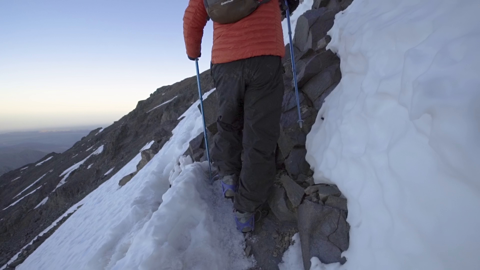

눈 덮인 암벽 산길에서 한 등산객이 주황색 재킷과 배낭을 착용하고 등산 스틱을 사용해 오르고 있다. 오른쪽에는 높은 눈벽이 있고, 왼쪽으로는 가파른 산비탈과 탁 트인 풍경이 보인다.


In [7]:
# 이미지 Base64 인코딩 및 GPT 멀티모달 호출
import base64
from openai import OpenAI
from PIL import Image
import os

# 이미지 파일을 base64 문자열로 반환하는 함수
def encode_image_to_base64(image_path):
    with open(image_path, 'rb') as f: # 바이너리로 이미지 파일 열기
        return base64.b64encode(f.read()).decode('utf-8') # base64 인코딩 -> 문자열 디코딩

# GPT 모델로 이미지 설명(캡션)을 생성하는 함수
def call_openai(client, model, image_b64):
    # API 호출
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                'role': 'system',
                'content': '''당신은 이미지에 대한 설명을 정확하고, 간략히 작성하는 **장면해설가**입니다.'''  # 역할 설정
            },
            {
                'role': 'user',
                'content': [
                    {
                        'type': 'text',
                        'text': '''아래 이미지는 동영사의 한 프레임입니다. 프레임의 주요특징과 장면을 간략하게 설명해주세요.'''  # 텍스트 지시문
                    },
                    {
                        'type': 'image_url',
                        'image_url': {
                            'url': f'data:image/jpeg;base64,{image_b64}'  # base64 이미지 전달
                        }
                    }
                ]
            }
        ]
    )
    return response.choices[0].message.content # 최종 텍스트 답변만 반환

client = OpenAI()
model = 'gpt-5.6-luna'
image_path = os.path.join(BASE_PATH, 'frames', 'alpinist', 'alpinist_frame00300.jpg')
image_b64 = encode_image_to_base64(image_path)  # 이미지 -> base64 변환

image= Image.open(image_path)
image.thumbnail((480,270)) # 크기 축소
display(image) # 이미지 표시

print(call_openai(client, model, image_b64)) # GPT 설명 출력


## 전체 이미지 캡셔닝

In [8]:
import re # 정규 표현식

# 프레임 파일명에서 숫자 프레임 번호를 정수로 추출하는 함수
def extract_frame_no(frame_file):
    match = re.search(r'_frame(\d+)\.jpg', frame_file) # '_frame' 뒤 숫자 캡쳐 + .jpg 형식인지 확인
    return int(match.group(1)) # 캡쳐된 숫자 문자열을 int 변환해서 반환

extract_frame_no('alpinist_frame00300.jpg')



300

In [9]:
# 프레임 디렉토리 경로 구성 및 프레임 파일 목록 불러오기
frame_dir_path = os.path.join(BASE_PATH, 'frames') # 프레임 이미지 폴더 경로
video_frame_dir_path = os.path.join(frame_dir_path, 'skiing') # skiing 프레임 폴더 경로
frame_files = [f for f in os.listdir(video_frame_dir_path) ]  # 파일명 리스트업
frame_files


['skiing_frame00000.jpg',
 'skiing_frame00030.jpg',
 'skiing_frame00060.jpg',
 'skiing_frame00090.jpg',
 'skiing_frame00120.jpg',
 'skiing_frame00150.jpg',
 'skiing_frame00180.jpg',
 'skiing_frame00210.jpg',
 'skiing_frame00240.jpg',
 'skiing_frame00270.jpg',
 'skiing_frame00300.jpg',
 'skiing_frame00330.jpg']

In [10]:
# 비디오별 프레임 이미지 캡션 생성 후 CSV 저장
import uuid # 고유 ID 생성 모듈
import pandas as pd
from tqdm.auto import tqdm
import os

# frames 폴더의 각 비디오 프레임을 순회하면서 이미지 설명을 생성하고, CSV로 저장하는 함수
def generate_frame_image_captions(frame_dir='frames', video_dir='videos', caption_dir='captions'):
    frame_dir_path = os.path.join(BASE_PATH, frame_dir) # 프레임 이미지 폴더 경로
    video_dir_path = os.path.join(BASE_PATH, video_dir) # 비디오 프레임 폴더 경로
    caption_dir_path = os.path.join(BASE_PATH, caption_dir) # captions 저장 폴더
    os.makedirs(caption_dir_path, exist_ok=True)

    video_names = [d for d in os.listdir(frame_dir_path)]

    for video_name in video_names:
        video_filename = f"{video_name}.mp4"
        video_frame_dir_path = os.path.join(frame_dir_path, video_name)
        frame_files = [f for f in os.listdir(video_frame_dir_path)]

        results = [] # 해당 비디오 프레임 설명 결과 리스트

        for frame_file in tqdm(frame_files, desc = f'{video_name} 프레임 해설 중'):
            frame_file_path = os.path.join(video_frame_dir_path, frame_file)
            image_b64 = encode_image_to_base64(frame_file_path)
            description = call_openai(client, model, image_b64)
            frame_no = extract_frame_no(frame_file)
            results.append({
                'id': str(uuid.uuid4()),    # 레코드 식별용 고유 UUID 생성
                'video_filename': video_filename,
                'frame_no': frame_no,       # 프레임 번호(정렬/검색용)
                'description': description  # 설명 텍스트
            })

        df = pd.DataFrame(results)
        csv_file_path = os.path.join(caption_dir_path, f'{video_name}_frames.csv')
        df.to_csv(csv_file_path, index=False, encoding='utf-8') # CSV 저장(인덱스 제외, UTF-8)
        print(f'{video_name} : {len(df)}개 프레임 이미지별 캡션 저장 완료!\n')

generate_frame_image_captions()

alpinist 프레임 해설 중:   0%|          | 0/23 [00:00<?, ?it/s]

alpinist : 23개 프레임 이미지별 캡션 저장 완료!



skiing 프레임 해설 중:   0%|          | 0/12 [00:00<?, ?it/s]

skiing : 12개 프레임 이미지별 캡션 저장 완료!



baseball 프레임 해설 중:   0%|          | 0/25 [00:00<?, ?it/s]

baseball : 25개 프레임 이미지별 캡션 저장 완료!



basketball 프레임 해설 중:   0%|          | 0/14 [00:00<?, ?it/s]

basketball : 14개 프레임 이미지별 캡션 저장 완료!



soccer 프레임 해설 중:   0%|          | 0/12 [00:00<?, ?it/s]

soccer : 12개 프레임 이미지별 캡션 저장 완료!

